# Data Loading, Pre-processing, EDA & Train/Test Split

This notebook introduces a simple, reusable workflow for preparing a dataset before machine learning.

**Dataset:** Breast Cancer Wisconsin (the same dataset used in the reference notebook)

**Workflow:**
1. Load and inspect the data
2. Clean and pre-process the data
3. Perform basic EDA
4. Separate features and target
5. Split into training and test sets
6. Scale features correctly

> Put `breast-cancer-wisconsin.csv` inside a `datasets/` folder next to this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

---
## 1. Load the dataset

Start by loading the CSV and checking its basic structure.

A few useful questions at this stage are:
- How many rows and columns are there?
- What are the column names and data types?
- Are there missing values?
- What does a typical row look like?
- How are the target classes distributed?

In [3]:
def load_cancer(path="../datasets/breast-cancer-wisconsin.csv"):
    df = pd.read_csv(path)
    df = df.replace("?", np.nan)      # '?' represents missing values
    df = df.drop(columns=["id"])      # id identifies a row; it is not a useful feature
    return df.astype(float)

df = load_cancer()

print("Shape           :", df.shape)
print("Columns         :", list(df.columns))
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nTarget counts (2 = benign, 4 = malignant):\n", df["class"].value_counts())

df.head()

Shape           : (699, 10)
Columns         : ['clump_thickness', 'size_uniformity', 'shape_uniformity', 'marginal_adhesion', 'epithelial_size', 'bare_nucleoli', 'bland_chromatin', 'normal_nucleoli', 'mitoses', 'class']

Data types:
 clump_thickness      float64
size_uniformity      float64
shape_uniformity     float64
marginal_adhesion    float64
epithelial_size      float64
bare_nucleoli        float64
bland_chromatin      float64
normal_nucleoli      float64
mitoses              float64
class                float64
dtype: object

Missing values:
 clump_thickness       0
size_uniformity       0
shape_uniformity      0
marginal_adhesion     0
epithelial_size       0
bare_nucleoli        16
bland_chromatin       0
normal_nucleoli       0
mitoses               0
class                 0
dtype: int64

Target counts (2 = benign, 4 = malignant):
 class
2.0    458
4.0    241
Name: count, dtype: int64


,clump_thickness,size_uniformity,shape_uniformity,marginal_adhesion,epithelial_size,bare_nucleoli,bland_chromatin,normal_nucleoli,mitoses,class
0,5.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,2.0
1,5.0,4.0,4.0,5.0,7.0,10.0,3.0,2.0,1.0,2.0
2,3.0,1.0,1.0,1.0,2.0,2.0,3.0,1.0,1.0,2.0
3,6.0,8.0,8.0,1.0,3.0,4.0,3.0,7.0,1.0,2.0
4,4.0,1.0,1.0,3.0,2.0,1.0,3.0,1.0,1.0,2.0


### What should you notice?

The `class` column is the target. In this dataset, `2` means benign and `4` means malignant.

`bare_nucleoli` contains missing values represented by `?`. We converted them to `NaN` so pandas and scikit-learn can handle them properly.

The `id` column was removed because it is an identifier, not a measurement that describes the tumour.

## 2. Basic pre-processing

### Missing values

A common beginner-friendly approach for numeric features is **median imputation**. The median is less sensitive to extreme values than the mean.

**Important:** for a real ML pipeline, calculate the median using the training set only. This prevents information from the test set leaking into the training process.

In [4]:
# Check how many missing values remain before imputation
print("Missing values before:", df.isna().sum().sum())

# For this exploratory notebook, fill numeric missing values with the median.
df = df.fillna(df.median(numeric_only=True))

print("Missing values after :", df.isna().sum().sum())

Missing values before: 16
Missing values after : 0


### Check for duplicate rows

Duplicate observations can distort analysis and model training. Always check before moving on.

In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 242


---
## 3. Exploratory Data Analysis (EDA)

EDA helps you understand the dataset before choosing or training a model.

We will use three simple plot types:
- **Bar/count plot:** compares category frequencies
- **Histogram:** shows the distribution of a numeric variable
- **Correlation heatmap:** shows how numeric variables move together

### 3.1 Bar plot — target distribution

A bar/count plot is useful for categorical variables such as the target class.

**What to look for:** if one class is much larger than another, the dataset is imbalanced. Accuracy alone can then be misleading.

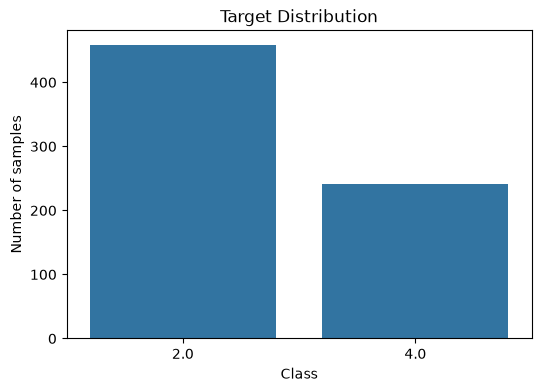

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x="class", data=df)
plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.show()

### 3.2 Histograms — feature distributions

A histogram shows how values are distributed across ranges (bins).

**What to look for:** skewness, concentration, multiple peaks, and unusual extreme values. These can affect how you preprocess or model the data.

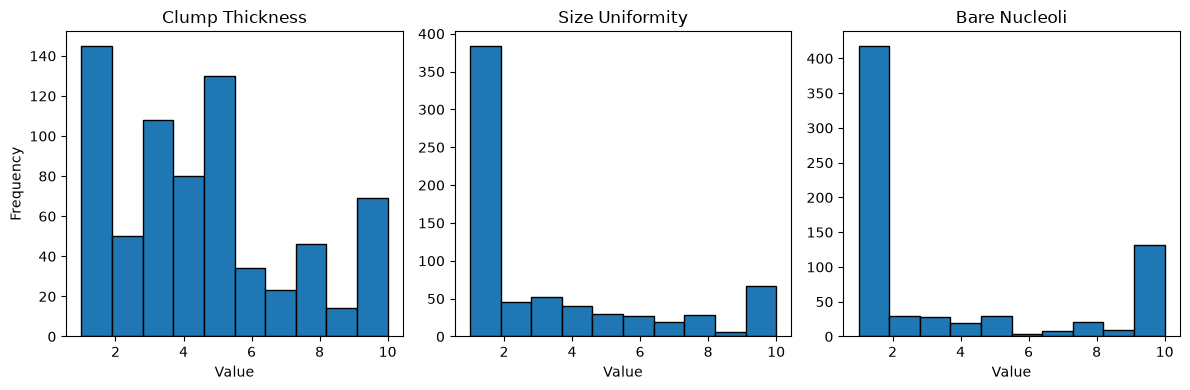

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(df["clump_thickness"], bins=10, edgecolor="black")
plt.title("Clump Thickness")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
plt.hist(df["size_uniformity"], bins=10, edgecolor="black")
plt.title("Size Uniformity")
plt.xlabel("Value")

plt.subplot(1, 3, 3)
plt.hist(df["bare_nucleoli"], bins=10, edgecolor="black")
plt.title("Bare Nucleoli")
plt.xlabel("Value")

plt.tight_layout()
plt.show()

### 3.3 Correlation heatmap

Correlation measures the strength and direction of a **linear relationship** between two numeric variables.

- Values close to `+1`: strong positive relationship
- Values close to `-1`: strong negative relationship
- Values close to `0`: weak linear relationship

**Use:** a heatmap can reveal redundant features and groups of strongly related variables. Correlation does not prove causation.

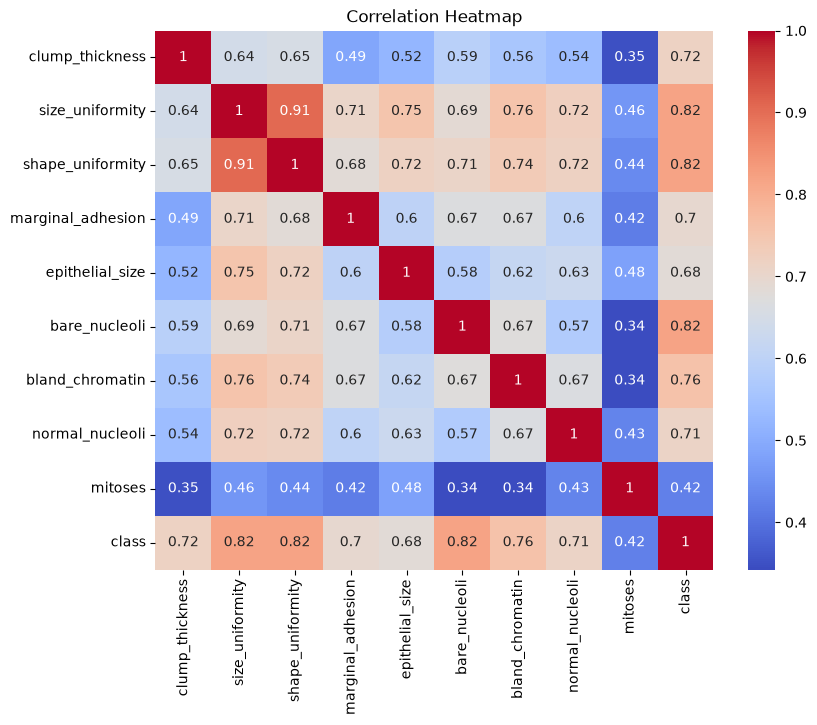

In [10]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

---
## 4. Separate features and target

`X` contains the input features. `y` contains the value we want the model to predict.

Here we convert the original target into a simpler binary target:
- `0` → benign
- `1` → malignant

In [ ]:
X = df.drop(columns=["class"])
y = (df["class"] == 4).astype(int)

print("Features:", X.shape)
print("Target  :", y.shape)
print("\nTarget counts:\n", y.value_counts())

## 5. Train/test split

The dataset should be divided before fitting transformations or models.

- **Training set:** used to learn parameters
- **Test set:** kept aside to estimate performance on unseen data

`stratify=y` keeps approximately the same class proportions in both sets, which is useful when classes are imbalanced.

`random_state=42` makes the split reproducible.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

## 6. Scale the features — after splitting

Some algorithms work better when features are on a similar scale. `StandardScaler` transforms a feature using its training-set mean and standard deviation.

**Critical rule:** fit the scaler on `X_train` only, then use that fitted scaler to transform both training and test data. Never fit the scaler on the full dataset before the split.

In [ ]:
scaler = StandardScaler().fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape :", X_test_scaled.shape)

---
## Quick checklist

Before training a model, you should be able to answer:

1. **Loaded:** Did I load the data correctly?
2. **Inspected:** Do I know the shape, columns, data types, and missing values?
3. **Cleaned:** Did I handle missing values, irrelevant columns, and duplicates appropriately?
4. **Explored:** Did I inspect class balance, feature distributions, and correlations?
5. **Split:** Did I create train and test sets before fitting transformations?
6. **Scaled:** If scaling is needed, did I fit the scaler on the training set only?

**Core idea:** understand the data first, then split it, then learn preprocessing parameters from the training data.